# GCAP3226 Week 3 - In-Class Exercise 1 (5%)

**Name:** ZHANG Yicheng  |  **Student ID (last 4 digits):** 4810  |  **Team:** T7
**Dataset:** `week3.csv` - MSW charging survey, n = 97 (non-probability sample)
**Tools:** Python in GitHub Codespaces (pandas, scikit-learn, statsmodels, matplotlib)

*All results describe this sample only. Coefficients are associations, not causal effects, and the
sample cannot be generalised to the Hong Kong population.*


## Setup


In [1]:
# Setup - load the Week 3 survey data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression

DATA_FILE = "week3.csv"


def load_week3_data():
    for p in [Path(DATA_FILE), Path.cwd() / DATA_FILE]:
        if p.is_file():
            print("Using data file:", p.resolve())
            return pd.read_csv(p)
    raise FileNotFoundError("Could not find week3.csv - run this notebook inside the Week 3 repo.")


df = load_week3_data()
print("shape:", df.shape)
print("columns:", list(df.columns))
print(df.head().to_string())


Using data file: C:\Users\zhang\Desktop\GCAP 3226\GCAP3226_week3\week3.csv
shape: (97, 12)
columns: ['ID', 'support_info', 'support_after_info', 'government_consideration', 'fairness', 'policy_helpfulness', 'waste_severity', 'recycling_effort', 'age_group', 'monthly_income', 'education', 'education_label']
   ID  support_info  support_after_info  government_consideration  fairness  policy_helpfulness  waste_severity  recycling_effort  age_group  monthly_income  education  education_label
0   1             1                   1                         1         1                   1               3                 1       29.5         22500.5          4  Master or above
1   2             5                   5                         5         5                   4               2                 2       39.5          7500.0          4  Master or above
2   3             3                   5                         4         5                   2               3                 1       2

## Task 1 - Stacked bar

Row-percentage stacked bar of `support_info` within each level of `fairness` (the demo pair used
`government_consideration`, so a different grouping variable is used here), with the group sizes
shown on the x axis.


support_info   1  2   3   4  5
fairness                      
1             13  2   0   0  0
2              4  9   3   2  0
3              1  6  10   7  1
4              2  2   9  18  4
5              0  0   1   0  3
support_info     1     2     3     4     5
fairness                                  
1             86.7  13.3   0.0   0.0   0.0
2             22.2  50.0  16.7  11.1   0.0
3              4.0  24.0  40.0  28.0   4.0
4              5.7   5.7  25.7  51.4  11.4
5              0.0   0.0  25.0   0.0  75.0


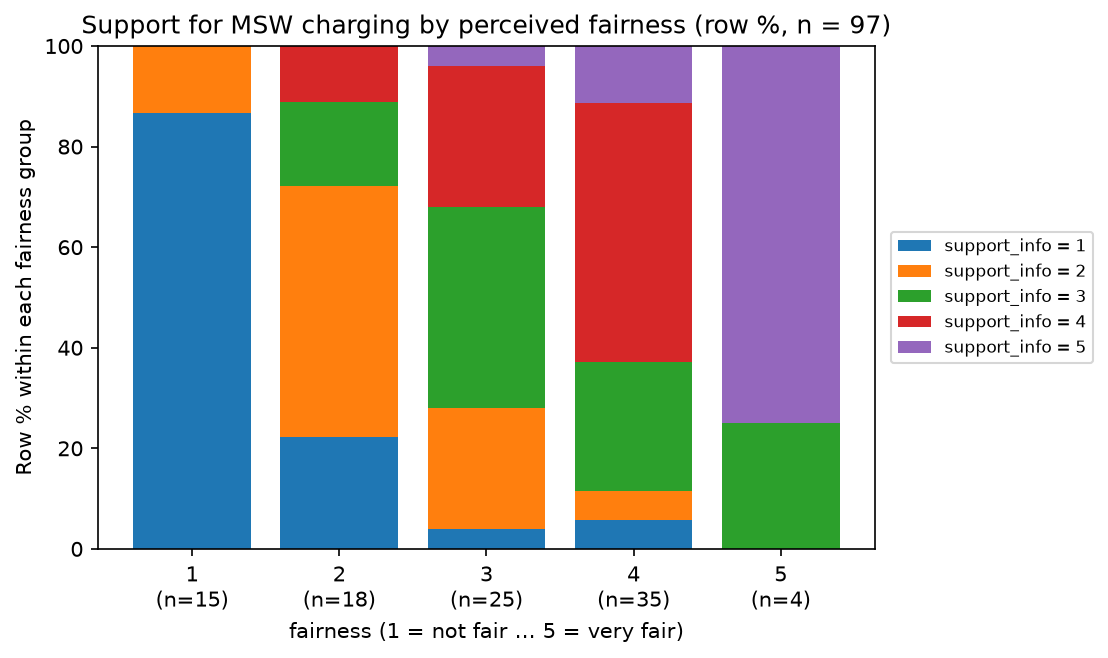

In [2]:
# Task 1 - row-percentage stacked bar: support_info within each fairness group
sub = df[["fairness", "support_info"]].dropna()

# Frequency table: rows = fairness level, columns = support level (1-5)
tab = pd.crosstab(sub["fairness"], sub["support_info"])

# Row percentages: each fairness group adds up to 100%
pct = tab.div(tab.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bottom = np.zeros(len(pct))
for lv in pct.columns:
    ax.bar(pct.index.astype(str), pct[lv].values, bottom=bottom,
           label="support_info = %s" % lv)
    bottom += pct[lv].values

# Group sizes in the tick labels so thin groups are visible
ax.set_xticks(range(len(pct.index)))
ax.set_xticklabels(["%s\n(n=%d)" % (g, int(tab.loc[g].sum())) for g in pct.index])
ax.set_xlabel("fairness (1 = not fair ... 5 = very fair)")
ax.set_ylabel("Row % within each fairness group")
ax.set_title("Support for MSW charging by perceived fairness (row %, n = 97)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

print(tab)
print(pct.round(1))


### Task 1 - What the chart shows

Support rises with perceived fairness in this sample. Among respondents who rate the scheme least
fair (fairness = 1, n = 15), 86.7% sit at support_info = 1 and none are at 4 or 5; among those who
rate it fair (fairness = 4, n = 35), 62.9% choose 4 or 5. The fairness = 5 group reaches 75% at
support 5, but it contains only 4 respondents, so that percentage is very unstable.

This is a positive association inside a non-probability sample of 97 respondents: it does not show
that perceived fairness causes support, and it cannot be generalised to Hong Kong.


## Task 2 - Multiple linear regression

`support_info` regressed on `government_consideration`, `fairness`, `policy_helpfulness` and
`waste_severity`, using complete cases.


In [3]:
# Task 2 - multiple linear regression with four exploratory variables
XS = ["government_consideration", "fairness", "policy_helpfulness", "waste_severity"]
d2 = df[["support_info"] + XS].dropna()          # complete cases only

model = LinearRegression().fit(d2[XS], d2["support_info"])

print("n =", len(d2))
print("R2 =", round(model.score(d2[XS], d2["support_info"]), 3))
print("intercept =", round(model.intercept_, 3))
for name, coef in zip(XS, model.coef_):
    print("  %-24s % .3f" % (name, coef))

# Standard errors and p-values (statsmodels, already installed in the Codespace)
import statsmodels.api as sm

m = sm.OLS(d2["support_info"], sm.add_constant(d2[XS])).fit()
print("\nstandard errors and p-values:")
for k in ["const"] + XS:
    print("  %-24s se = %.3f   p = %.4f" % (k, m.bse[k], m.pvalues[k]))


n = 97
R2 = 0.639
intercept = -0.277
  government_consideration  0.483
  fairness                  0.379
  policy_helpfulness        0.192
  waste_severity            0.118

standard errors and p-values:
  const                    se = 0.400   p = 0.4910
  government_consideration se = 0.115   p = 0.0001
  fairness                 se = 0.104   p = 0.0004
  policy_helpfulness       se = 0.112   p = 0.0894
  waste_severity           se = 0.141   p = 0.4043


### Task 2 - Coefficients, R-squared and n

| Variable | Coefficient | Std. error | p-value |
|---|---|---|---|
| Intercept | -0.277 | 0.400 | 0.491 |
| government_consideration | **0.483** | 0.115 | **0.0001** |
| fairness | **0.379** | 0.104 | **0.0004** |
| policy_helpfulness | 0.192 | 0.112 | 0.089 |
| waste_severity | 0.118 | 0.141 | 0.404 |

**R-squared = 0.639** (adjusted R-squared = 0.623), **n = 97**.

**Interpretation.** Holding the other three variables fixed, a one-point higher rating of
"the government considered diverse opinions" is associated with roughly 0.48 points higher initial
support for MSW charging; holding the other variables fixed, a one-point higher fairness rating is
associated with roughly 0.38 points higher support. `policy_helpfulness` and `waste_severity` are
also positive but smaller and cannot be distinguished from zero at the 5% level (p = 0.089 and
p = 0.404).

**Caution.** Cross-sectional, self-reported data from a non-probability sample of 97, so these are
associations only. `fairness` and `government_consideration` are strongly correlated (r = 0.73),
which makes their separate coefficients less precise, and the 1-5 scale is ordinal but treated as
numeric here.


## Task 3 - Simple linear regression with my own AI prompt

**Input -> Process -> Output prompt written for this task:**

```text
Input:    dataframe df already loaded from week3.csv (97 respondents).
Process:  Write Python code to run a simple linear regression with response = support_info and
          one exploratory variable = fairness. Use rows with no missing values on these two
          columns. Print the intercept, the fairness slope, R-squared and n, then draw a scatter
          plot of the two variables with the fitted line.
Output:   printed intercept, slope, R-squared and n, plus a scatter plot with the regression line.
```


n = 97
R2 = 0.522
intercept = 0.495
fairness slope = 0.794


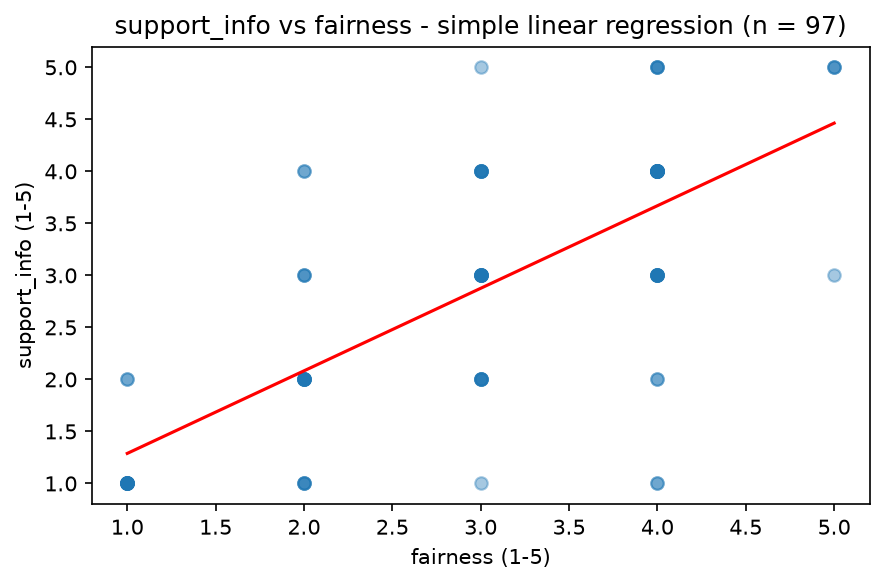

In [4]:
# Task 3 - simple linear regression: support_info ~ fairness
d3 = df[["support_info", "fairness"]].dropna()
simple = LinearRegression().fit(d3[["fairness"]], d3["support_info"])

print("n =", len(d3))
print("R2 =", round(simple.score(d3[["fairness"]], d3["support_info"]), 3))
print("intercept =", round(simple.intercept_, 3))
print("fairness slope =", round(simple.coef_[0], 3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(d3["fairness"], d3["support_info"], alpha=0.4)
xs = np.linspace(d3["fairness"].min(), d3["fairness"].max(), 50)
ax.plot(xs, simple.intercept_ + simple.coef_[0] * xs, color="red")
ax.set_xlabel("fairness (1-5)")
ax.set_ylabel("support_info (1-5)")
ax.set_title("support_info vs fairness - simple linear regression (n = 97)")
plt.tight_layout()
plt.show()


### Task 3 - Note on the fairness slope

The simple regression gives `support_info = 0.495 + 0.794 x fairness` (R-squared = 0.522): each
one-point higher fairness rating is associated with about 0.79 points higher support.

In the Task 2 multiple regression the fairness coefficient falls to 0.379, because fairness and
`government_consideration` move together (r = 0.73). Once the government-consideration rating is in
the model, part of what looked like a fairness effect is already accounted for by it. Both
coefficients stay positive and significant in this sample.
